# IDA117V Practice Run-Through — Titanic Dataset
This notebook mirrors the **exact Test Scope structure (Part 1–10 + Bonus)**. Run every cell top to bottom so the code becomes familiar in your hands before Saturday. On test day, swap `titanic.csv` and the column names for whatever dataset you're given — the *shape* of the code stays identical.

**Target column (what we predict):** `Survived` (0 = did not survive, 1 = survived)

## Part 0 — Imports

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Outlier / anomaly detection
from sklearn.ensemble import IsolationForest

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")


## Part 1 — Dataset Exploration (10 marks)

In [2]:
df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


## Part 2 — Exploratory Data Analysis (EDA)

In [7]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

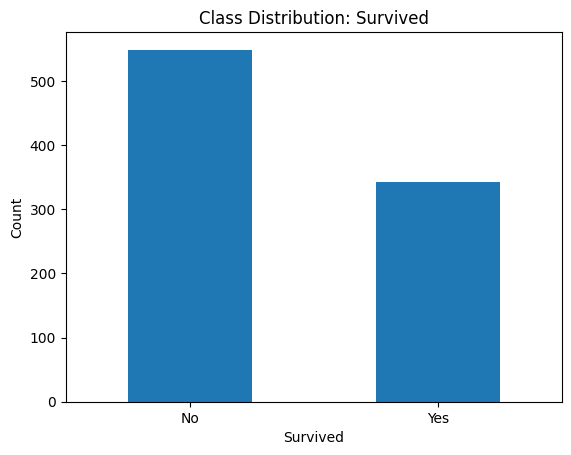

In [8]:
df["Survived"].value_counts().plot(kind="bar")
plt.title("Class Distribution: Survived")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.xticks([0,1], ["No", "Yes"], rotation=0)
plt.show()

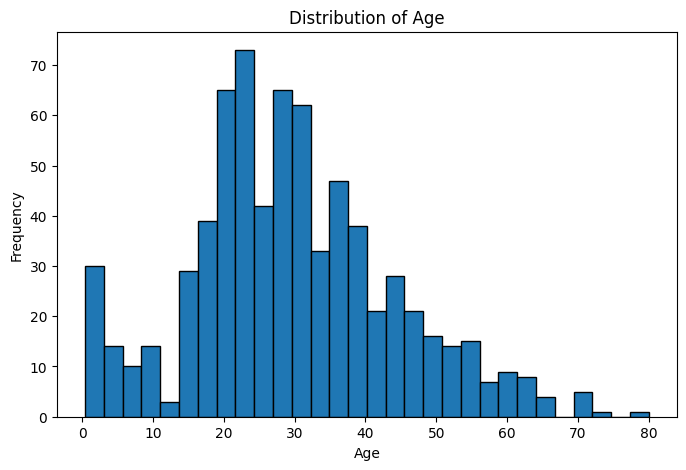

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"].dropna(), bins=30, edgecolor="black")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

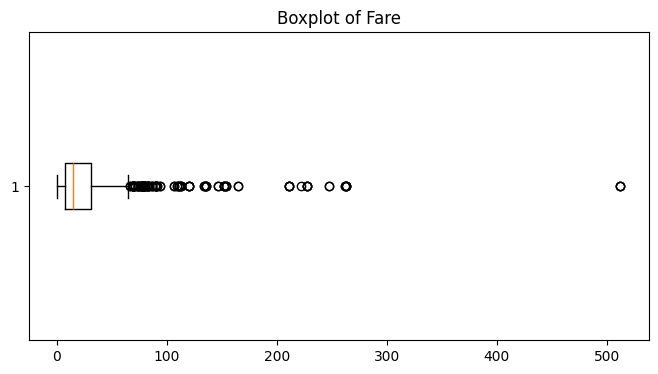

In [10]:
plt.figure(figsize=(8,4))
plt.boxplot(df["Fare"], vert=False)
plt.title("Boxplot of Fare")
plt.show()

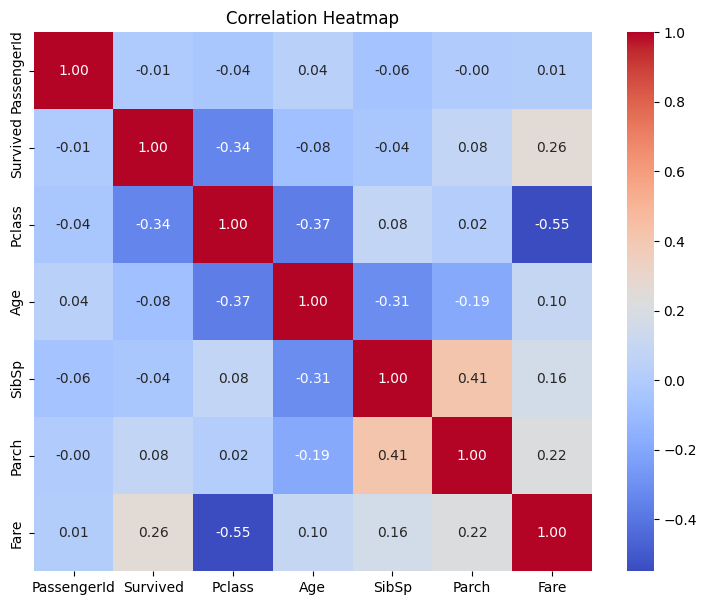

In [11]:
plt.figure(figsize=(9,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

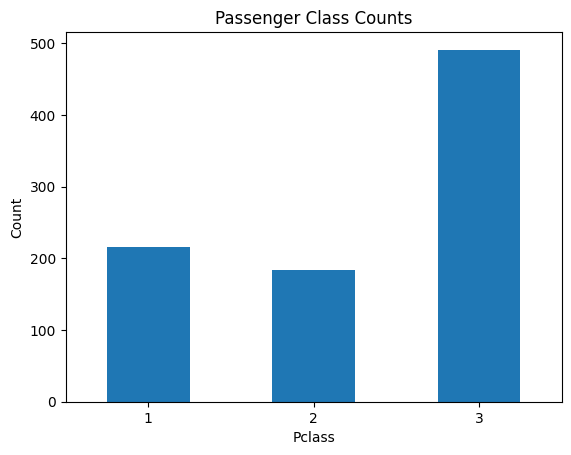

In [12]:
df["Pclass"].value_counts().sort_index().plot(kind="bar")
plt.title("Passenger Class Counts")
plt.xlabel("Pclass")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## Part 3 — Missing Values

In [13]:
missing_values = df.isnull().sum()
missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing %": (missing_values / len(df) * 100).round(2)
})
missing_table = missing_table[missing_table["Missing Values"] > 0].sort_values("Missing Values", ascending=False)
missing_table

,Missing Values,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


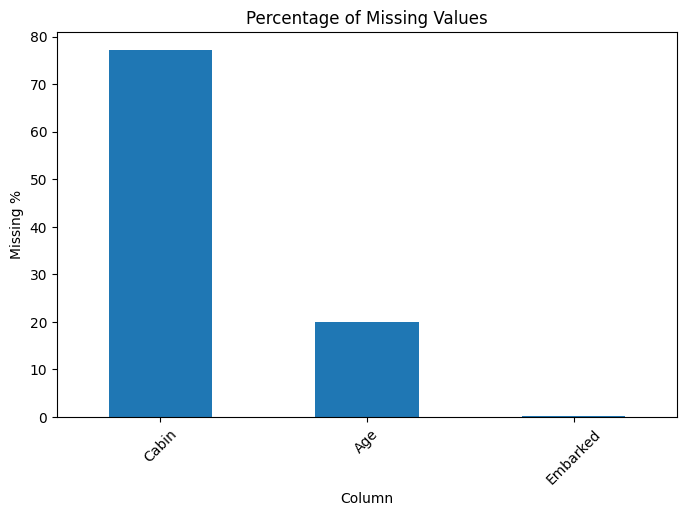

In [14]:
missing_table["Missing %"].plot(kind="bar", figsize=(8,5))
plt.title("Percentage of Missing Values")
plt.xlabel("Column")
plt.ylabel("Missing %")
plt.xticks(rotation=45)
plt.show()

In [15]:
# Numerical -> median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Categorical -> mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Mostly-missing column -> drop
df = df.drop(columns=["Cabin"])

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Part 4 — Outlier Detection

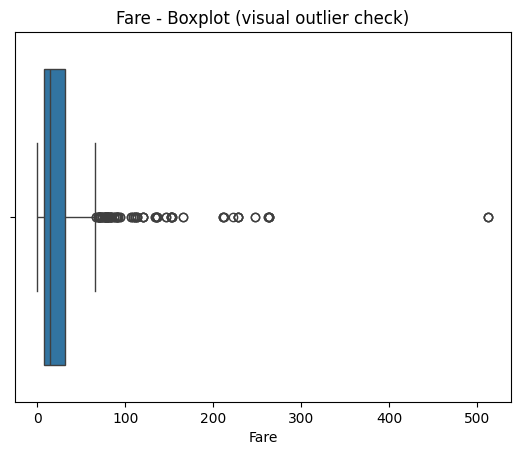

In [16]:
sns.boxplot(x=df["Fare"])
plt.title("Fare - Boxplot (visual outlier check)")
plt.show()

In [17]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

fare_outliers = df[(df["Fare"] < lower_bound) | (df["Fare"] > upper_bound)]
print("Number of Fare outliers:", len(fare_outliers))
fare_outliers[["PassengerId", "Fare"]].head(10)

Number of Fare outliers: 116


,PassengerId,Fare
1,2,71.2833
27,28,263.0000
31,32,146.5208
34,35,82.1708
52,53,76.7292
61,62,80.0000
62,63,83.4750
72,73,73.5000
88,89,263.0000
102,103,77.2875


## Part 5 — Anomaly Detection

In [18]:
anomaly_data = df[["Age", "Fare"]].copy()

iso_forest = IsolationForest(contamination=0.05, random_state=42)
df["Anomaly"] = iso_forest.fit_predict(anomaly_data)

df["Anomaly"].value_counts()

Anomaly
 1    846
-1     45
Name: count, dtype: int64

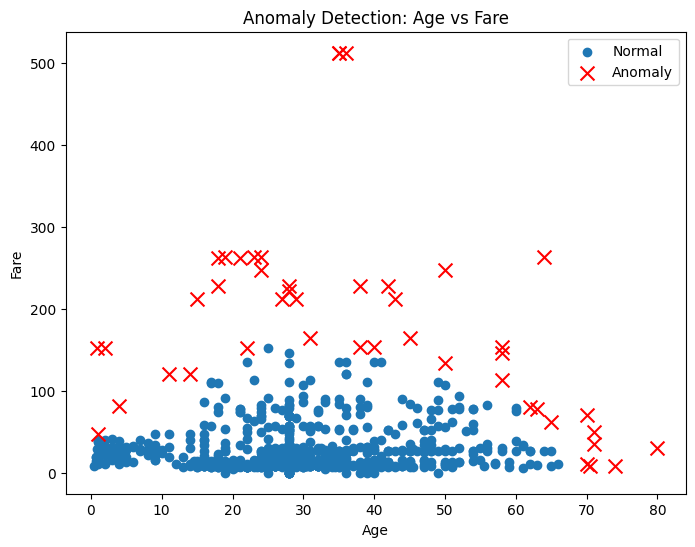

In [19]:
normal = df[df["Anomaly"] == 1]
anomalies = df[df["Anomaly"] == -1]

plt.figure(figsize=(8,6))
plt.scatter(normal["Age"], normal["Fare"], label="Normal")
plt.scatter(anomalies["Age"], anomalies["Fare"], marker="x", s=100, color="red", label="Anomaly")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Anomaly Detection: Age vs Fare")
plt.legend()
plt.show()

## Part 6 — Feature Selection (Pre-processing)

In [20]:
print("Numerical columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical columns:")
print(df.select_dtypes(include="object").columns.tolist())

Numerical columns:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Anomaly']

Categorical columns:
['Name', 'Sex', 'Ticket', 'Embarked']


In [21]:
FEATURES = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
TARGET = "Survived"

X = df[FEATURES].copy()
y = df[TARGET].copy()

CATEGORICAL_FEATURES = ["Sex", "Embarked"]
NUMERICAL_FEATURES = [c for c in FEATURES if c not in CATEGORICAL_FEATURES]

X = pd.get_dummies(X, columns=CATEGORICAL_FEATURES, drop_first=True)
X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


## Part 7 — Train/Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 80/20 split -- CHANGE if the question specifies a different ratio
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 712
Testing samples: 179


In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on TRAIN only
X_test_scaled = scaler.transform(X_test)         # transform only on TEST

## Part 8 — Logistic Regression Model

In [24]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

Accuracy: 0.8045


## Part 9 — Model Evaluation

In [25]:
print(classification_report(y_test, y_pred, target_names=["Did not survive", "Survived"]))

                 precision    recall  f1-score   support

Did not survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



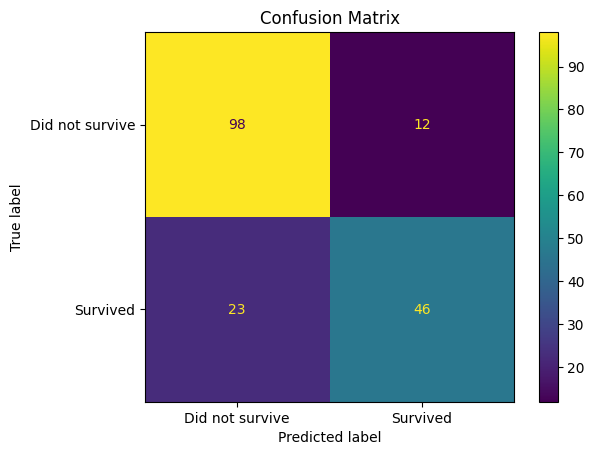

In [26]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Did not survive", "Survived"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

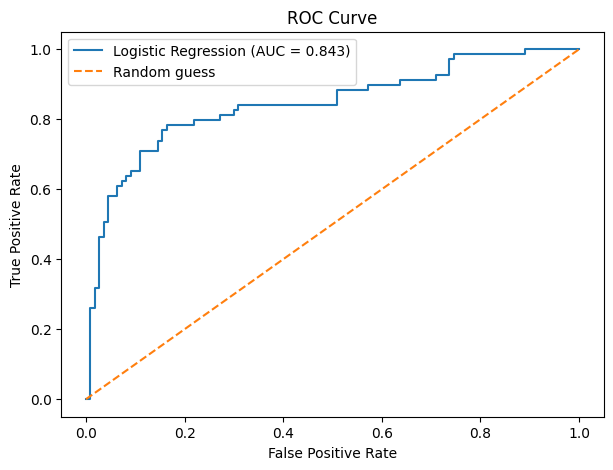

ROC-AUC score: 0.8433


In [27]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC score:", round(auc, 4))

## Part 10 — Model Interpretation
Write this as prose in a markdown cell in the real test. Example based on the numbers above:

> The confusion matrix shows the model correctly identified most passengers who did not survive (high true negatives) and correctly identified a good portion of survivors (true positives), with some false positives/negatives. The ROC curve bows toward the top-left, and an AUC around 0.85 means the model is quite good at ranking a random survivor higher than a random non-survivor. The accuracy score reflects the overall percentage of correct predictions on unseen (test) data — since survival classes are somewhat imbalanced (more people died than survived), precision/recall per class give a fuller picture than accuracy alone.

## Bonus — Decision Tree, Random Forest, Comparison

In [28]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_pred = dt_model.predict(X_test_scaled)
dt_acc = accuracy_score(y_test, dt_pred)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, rf_pred)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [accuracy, dt_acc, rf_acc]
})
comparison

,Model,Accuracy
0,Logistic Regression,0.804469
1,Decision Tree,0.821229
2,Random Forest,0.815642
